<p class="h1">ECE 447 - Notebook 16</p>
<p class="h2">Autoencoders</p>

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import torchvision
from tqdm import tqdm
from torchvision.transforms import v2

import matplotlib.pyplot as plt

In [34]:
params = {
    # "model": "LinearAutoencoder",
    # "model": "NonLinearAutoencoder",
    "model": "SparseAutoencoder",
    ### data
    "dataset": "MNIST",
    "data_dim": 784,
    "num_classes": 10,
    ### data loader
    "shuffle": True,
    "batch_size": 256,
    "num_workers": 4,
    ### optimizer
    "optimizer_name": "AdamW",
    "optimizer_lr": 1e-3,
    "optimizer_weight_decay": 0,
    ### network
    "latent_dim": 128,
    "k": 10,
    ### optimizer_scheduler
    "optimizer_scheduler": "StepLR",
    "optimizer_scheduler_gamma": None,
    "optimizer_scheduler_patience": None,
    "optimizer_scheduler_tmax": None,
    "optimizer_scheduler_stepsize": 10,
    "optimizer_scheduler_gamma": 0.5,
    ### loss
    "loss_name": "MSE",
    ### train related
    "num_epochs": 20,
    "tqdm_prints_disable": False,
    "disable_inner_loop": False,
    }

# device = "cpu" # for cpu
# device = "cuda:0" # for nvidia
device = "mps:0" # for mac with gpu

In [35]:
# load datasets

if params["dataset"] == "MNIST":
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    dataset = torchvision.datasets.MNIST("data", train=True, transform=transform, download=True)
    train_dataset = torch.utils.data.Subset(dataset, range(50000))
    test_dataset = torch.utils.data.Subset(dataset, range(50000, len(dataset)))

elif params["dataset"] == "RotatedMNIST":
    rotation_angle = params.get('rotation_angle', 45)  # default 45 degrees
    transform = v2.Compose([
        v2.ToImage(), 
        v2.ToDtype(torch.float32, scale=True),
        v2.RandomRotation(degrees=rotation_angle)
    ])
    dataset = torchvision.datasets.MNIST("data", train=True, transform=transform, download=True)
    train_dataset = torch.utils.data.Subset(dataset, range(50000))
    test_dataset = torch.utils.data.Subset(dataset, range(50000, len(dataset)))

elif params["dataset"] == "CIFAR10":
    transform = v2.Compose([
        v2.ToImage(), 
        v2.ToDtype(torch.float32, scale=True),
    ])
    dataset = torchvision.datasets.CIFAR10(
        "data", train=True, transform=transform, download=True
        )
    train_dataset = torch.utils.data.Subset(dataset, range(40000))
    test_dataset = torch.utils.data.Subset(dataset, range(40000, len(dataset)))


In [36]:
# create loaders

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=params["shuffle"],
    batch_size=params["batch_size"],
    num_workers=params["num_workers"],
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, shuffle=False, batch_size=1, num_workers=params["num_workers"],
)

In [45]:
# define the model class

class LinearAutoencoder(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        latent_dim,
    ):
        super(LinearAutoencoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # create the encoder and the decoder
        self.enc = torch.nn.Linear(self.input_dim, self.latent_dim, bias=False)
        self.decoder = torch.nn.Linear(self.latent_dim, self.input_dim, bias=False)

    def encoder(self, data):
        return self.enc(data)

    def forward(self, data):
        # encode the input to the latent space
        latent = self.encoder(data)
        
        # decode the latent representation back into the input space
        recons = self.decoder(latent)
        return recons

class NonLinearAutoencoder(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        latent_dim,
    ):
        super(NonLinearAutoencoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim
    
        # create the encoder and the decoder
        self.enc = torch.nn.Linear(self.input_dim, self.latent_dim)
        self.decoder = torch.nn.Linear(self.latent_dim, self.input_dim)

    def encoder(self, x):
        return F.relu(self.enc(x))
            
    def forward(self, data):
        # encode the input to the latent space
        latent = self.encoder(data)
        
        # decode the latent representation back into the input space
        recons = self.decoder(latent)
        
        # output the latent representation too so we can use it for sparsity
        return recons
    

class SparseAutoencoder(torch.nn.Module):
    def __init__(
        self,
        input_dim,
        latent_dim,
        k
    ):
        super(SparseAutoencoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.k = k
    
        # create the encoder and the decoder
        self.enc = torch.nn.Linear(self.input_dim, self.latent_dim)
        self.decoder = torch.nn.Linear(self.latent_dim, self.input_dim)

    def sparse_act_func(self, latent):
        device = latent.device
        values, indices = torch.topk(
            latent,
            k=self.k,
            dim=1,
        )
        latent = torch.zeros(latent.shape[0], latent.shape[1], device=device).scatter_(
            1, indices, values
        )
        return latent

    def encoder(self, x):
        latent = F.relu(self.enc(x))
        
        # sparsifying nonlinearity
        latent = self.sparse_act_func(latent)

        return latent

    def forward(self, data):
        # encode the input to the latent space
        latent = self.encoder(data)

        # decode the latent representation back into the input space
        recons = self.decoder(latent)
        
        # output the latent representation too so we can use it for sparsity
        return recons

In [ ]:
# build the network

if params["model"] == "LinearAutoencoder":
    net = LinearAutoencoder(input_dim=params["data_dim"], latent_dim=params["latent_dim"])
elif params["model"] == "NonLinearAutoencoder":
    net = NonLinearAutoencoder(input_dim=params["data_dim"], latent_dim=params["latent_dim"])
elif params["model"] == "SparseAutoencoder":
    net = SparseAutoencoder(input_dim=params["data_dim"], latent_dim=params["latent_dim"], k=params["k"])

net.to(device)

SparseAutoencoder(
  (enc): Linear(in_features=784, out_features=128, bias=True)
  (decoder): Linear(in_features=128, out_features=784, bias=True)
)

In [40]:
# setup optimizer
if params["optimizer_name"] == "AdamW":
    optimizer = torch.optim.AdamW(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )
elif params["optimizer_name"] == "Adam":
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )
elif params["optimizer_name"] == "SGD":
    optimizer = torch.optim.SGD(
        net.parameters(),
        lr=params["optimizer_lr"],
        weight_decay=params["optimizer_weight_decay"],
    )

In [41]:
# setup lr scheduler
  
if params["optimizer_scheduler"] == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        factor=params["optimizer_scheduler_gamma"],
        patience=params["optimizer_scheduler_patience"],
        mode="min",
    )
elif params["optimizer_scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=params["optimizer_scheduler_tmax"]
    )
elif params["optimizer_scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=params["optimizer_scheduler_stepsize"],
        gamma=params["optimizer_scheduler_gamma"],
    )
else:
    raise ValueError(f"Scheduler name is not implemented!")

In [42]:
# create loss function to be used to train your network

if params["loss_name"] == "MSE":
    criterion = torch.nn.MSELoss()
elif params["loss_name"] == "L1loss":
    criterion = torch.nn.L1Loss()
elif params["loss_name"] == "SmoothL1Loss":
    criterion = torch.nn.SmoothL1Loss()
elif params["loss_name"] == "CrossEnt":
    criterion =  torch.nn.CrossEntropyLoss()

In [43]:
# train loop

print("start training.")

net.train()

step = 0
loss_all = list()
loss_ae_all = list()
step_all = list()
for epoch in tqdm(
    range(params["num_epochs"]), disable=params["tqdm_prints_disable"]
):
    net.train()

    for idx, (x, y) in tqdm(enumerate(train_loader), disable=params["disable_inner_loop"]): # x is the image, y is its label

        step += 1

        # flatten
        x = torch.flatten(x, 1)

        # sent data into device (e.g., gpu)   
        x = x.to(device)
        y = y.to(device)

        # forward map prediction
        xhat = net(x)

        # compute the loss
        loss = criterion(x, xhat)

        # reset the gradients
        optimizer.zero_grad(set_to_none=True)
        # backward to compute the gradients
        loss.backward()

        # take a gradient descent step
        optimizer.step()
  
        if step %200 == 0:
            print("loss", loss)   

        loss_all.append(loss.item())
        step_all.append(step)


    # scheduler
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(loss)
    else:
        scheduler.step()


start training.


196it [00:01, 99.86it/s] :00<?, ?it/s]
  5%|▌         | 1/20 [00:02<00:38,  2.01s/it]

loss tensor(0.0323, device='mps:0', grad_fn=<MseLossBackward0>)


196it [00:01, 100.30it/s]
 10%|█         | 2/20 [00:03<00:35,  1.99s/it]

loss tensor(0.0287, device='mps:0', grad_fn=<MseLossBackward0>)


...

196it [00:01, 99.00it/s] 
 90%|█████████ | 18/20 [00:35<00:04,  2.00s/it]

loss tensor(0.0245, device='mps:0', grad_fn=<MseLossBackward0>)


196it [00:01, 98.44it/s] 
 95%|█████████▌| 19/20 [00:37<00:02,  2.01s/it]

loss tensor(0.0251, device='mps:0', grad_fn=<MseLossBackward0>)


196it [00:01, 98.58it/s] 
100%|██████████| 20/20 [00:39<00:00,  1.99s/it]


SparseAutoencoder


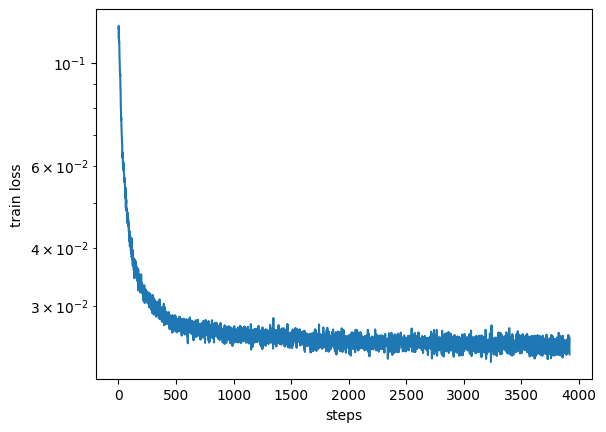

In [46]:
print(params["model"])

plt.figure()
plt.plot(step_all, loss_all)
plt.xlabel("steps")
plt.ylabel("train loss")
plt.yscale("log")
plt.show()

visualize decoder weights
torch.Size([784, 128])


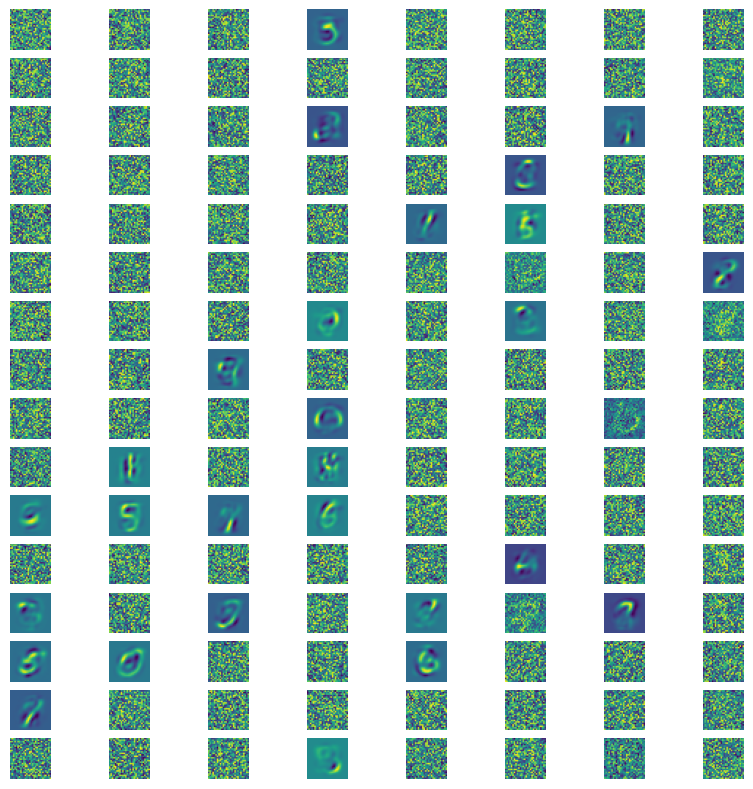

In [47]:
print("visualize decoder weights")

print(net.decoder.weight.shape)
fig, axes = plt.subplots(16, 8, figsize=(10,10))

idx = 0
for row in axes:
    for col in row:
        img = net.decoder.weight.T[idx, :].reshape(28, 28).cpu().detach().numpy()
        col.imshow(img)
        col.axis("off")
        idx += 1
plt.show()

visualize latents


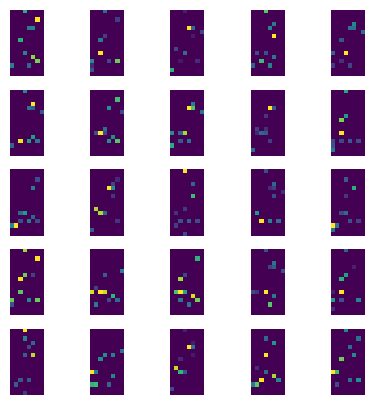

In [48]:
print("visualize latents")

fig, axes = plt.subplots(5, 5, figsize=(5,5))

for row in axes:
    for col in row:
        i = np.random.choice(3000, 1)
        x_test = test_dataset[idx][0].flatten(1).to(device)
        z = net.encoder(x_test)
        col.imshow(z.reshape(16,8).cpu().detach().numpy())
        col.axis("off")
        idx += 1
plt.show()

visualize images


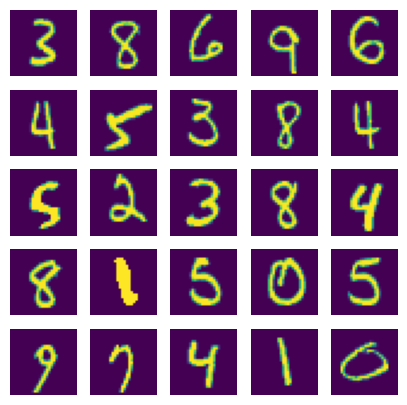

visualize reconstructions


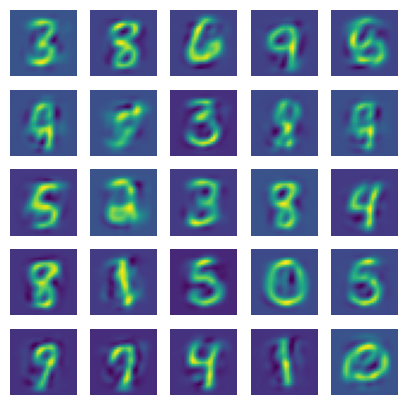

In [49]:
print("visualize images")
fig, axes = plt.subplots(5, 5, figsize=(5,5))
idx = 0
for row in axes:
    for col in row:
        x_test = test_dataset[idx][0].flatten(1).to(device)
        col.imshow(x_test.reshape(28,28).cpu().detach().numpy())
        col.axis("off")
        idx += 1
plt.show()

print("visualize reconstructions")
fig, axes = plt.subplots(5, 5, figsize=(5,5))
idx = 0
for row in axes:
    for col in row:
        x_test = test_dataset[idx][0].flatten(1).to(device)
        xhat = net(x_test)
        col.imshow(xhat.reshape(28,28).cpu().detach().numpy())
        col.axis("off")
        idx += 1
plt.show()